# 🗑️ Week 6: TrashNet Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to perform an Exploratory Data Analysis (EDA) on the TrashNet dataset. This analysis helps in understanding the dataset before training a machine learning model.

## Tasks Performed

- Load the TrashNet dataset from Google Drive.
- Count the number of images in each waste category.
- Display random sample images from each class.
- Analyze image dimensions and file sizes.
- Detect any corrupt or unreadable images.
- Create a stratified train, validation, and test split (70% / 15% / 15%).
- Save the split information as CSV files for reproducibility.
- Record observations about class distribution and image characteristics.

## Dataset Information

**Dataset Name:** TrashNet

**Number of Classes:** 6

- Cardboard
- Glass
- Metal
- Paper
- Plastic
- Trash

## Tools and Libraries

- Python
- Google Colab
- NumPy
- Pandas
- Matplotlib
- Pillow (PIL)
- Scikit-learn

## Expected Outcome

By the end of this notebook, the TrashNet dataset will be explored, analyzed, and prepared for model training in the next phase of the project.

Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import Libraries

In [2]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split

Set Dataset Path

In [3]:
DATASET_PATH = "/content/drive/MyDrive/data/trashnet"

Check that it works:

In [4]:
print(os.listdir(DATASET_PATH))

['trash', 'glass', 'cardboard', 'metal', 'plastic', 'paper']


Count Images Per Class

In [5]:
class_counts = {}

for class_name in sorted(os.listdir(DATASET_PATH)):

    class_path = os.path.join(DATASET_PATH, class_name)

    if os.path.isdir(class_path):

        count = len([
            file for file in os.listdir(class_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        class_counts[class_name] = count

print("📊 Image Count Per Class\n")

for cls, count in class_counts.items():
    print(f"{cls:<10}: {count}")

📊 Image Count Per Class

cardboard : 403
glass     : 501
metal     : 410
paper     : 594
plastic   : 482
trash     : 137


Display 10 Random Images Per Class

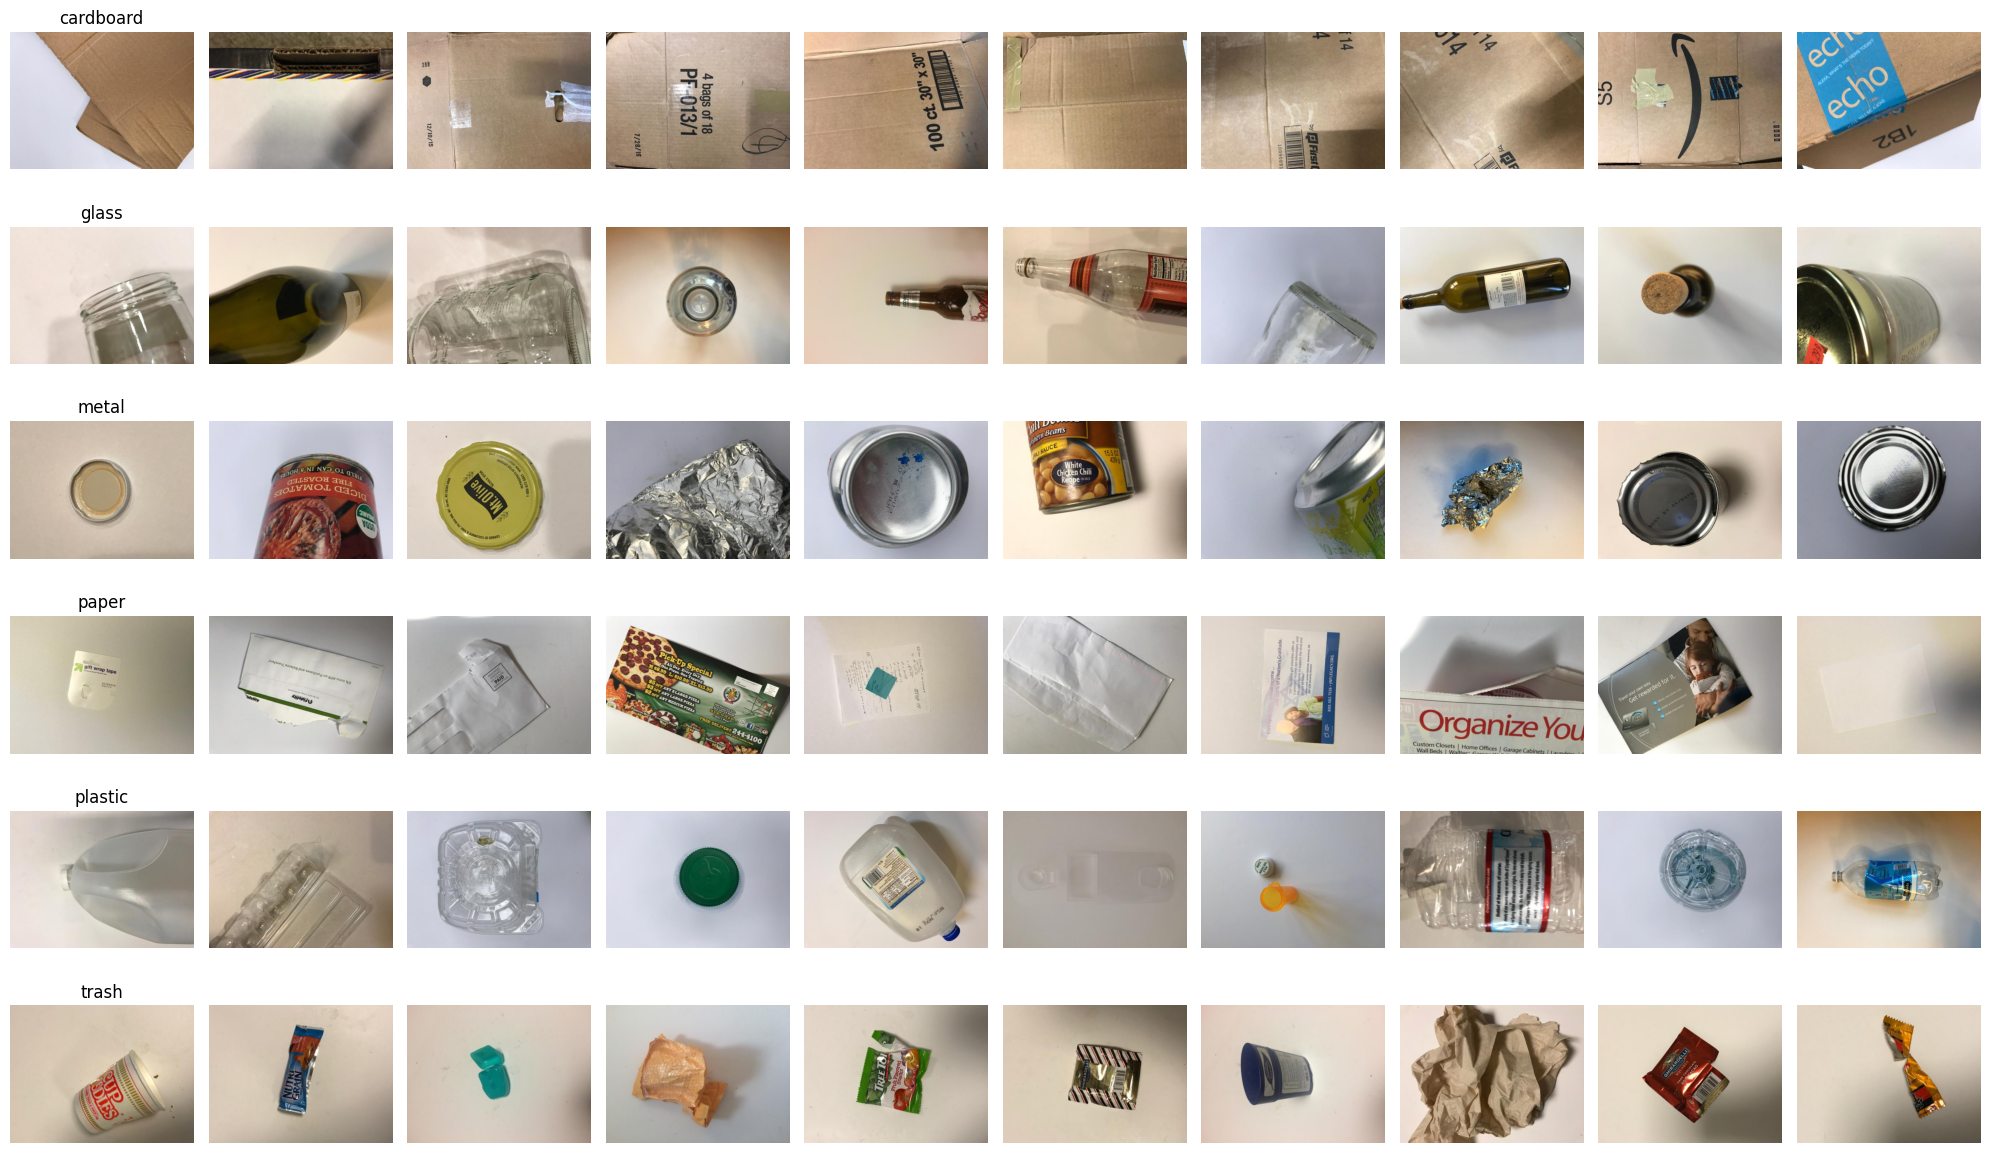

In [6]:
classes = sorted(os.listdir(DATASET_PATH))

fig, axes = plt.subplots(len(classes), 10, figsize=(20,12))

for row, class_name in enumerate(classes):

    folder = os.path.join(DATASET_PATH, class_name)

    images = random.sample(os.listdir(folder), 10)

    for col, image_name in enumerate(images):

        img = Image.open(os.path.join(folder, image_name))

        axes[row, col].imshow(img)
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_title(class_name)

plt.tight_layout()
plt.show()

Basic Image Statistics

In [7]:
widths = []
heights = []
file_sizes = []

for class_name in os.listdir(DATASET_PATH):

    folder = os.path.join(DATASET_PATH, class_name)

    if not os.path.isdir(folder):
        continue

    for image_name in os.listdir(folder):

        path = os.path.join(folder, image_name)

        try:
            img = Image.open(path)

            widths.append(img.width)
            heights.append(img.height)

            file_sizes.append(os.path.getsize(path) / 1024)

        except:
            pass

print("Total Images :", len(widths))
print("Average Width :", round(sum(widths)/len(widths),2))
print("Average Height:", round(sum(heights)/len(heights),2))
print("Average File Size (KB):", round(sum(file_sizes)/len(file_sizes),2))

Total Images : 2527
Average Width : 512.0
Average Height: 384.0
Average File Size (KB): 16.73


Check for Corrupt Images

In [8]:
corrupt = []

for class_name in os.listdir(DATASET_PATH):

    folder = os.path.join(DATASET_PATH, class_name)

    if not os.path.isdir(folder):
        continue

    for image_name in os.listdir(folder):

        path = os.path.join(folder, image_name)

        try:
            img = Image.open(path)
            img.verify()

        except:
            corrupt.append(path)

print("Number of corrupt images:", len(corrupt))

for img in corrupt:
    print(img)

Number of corrupt images: 0


Create Train, Validation, and Test Split

In [9]:
image_paths = []
labels = []

for class_name in os.listdir(DATASET_PATH):

    folder = os.path.join(DATASET_PATH, class_name)

    if not os.path.isdir(folder):
        continue

    for image_name in os.listdir(folder):

        image_paths.append(os.path.join(folder, image_name))
        labels.append(class_name)

Now split the data:

In [10]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("Training Images :", len(train_paths))
print("Validation Images:", len(val_paths))
print("Test Images :", len(test_paths))

Training Images : 1768
Validation Images: 379
Test Images : 380


Save CSV Files

In [11]:
import os

os.makedirs("/content/splits", exist_ok=True)

pd.DataFrame({
    "image": train_paths,
    "label": train_labels
}).to_csv("/content/splits/train.csv", index=False)

pd.DataFrame({
    "image": val_paths,
    "label": val_labels
}).to_csv("/content/splits/val.csv", index=False)

pd.DataFrame({
    "image": test_paths,
    "label": test_labels
}).to_csv("/content/splits/test.csv", index=False)

print("✅ CSV files saved successfully!")

✅ CSV files saved successfully!


If you want to keep these CSV files in your Google Drive, use:

In [12]:
os.makedirs("/content/drive/MyDrive/data/splits", exist_ok=True)

pd.DataFrame({
    "image": train_paths,
    "label": train_labels
}).to_csv("/content/drive/MyDrive/data/splits/train.csv", index=False)

pd.DataFrame({
    "image": val_paths,
    "label": val_labels
}).to_csv("/content/drive/MyDrive/data/splits/val.csv", index=False)

pd.DataFrame({
    "image": test_paths,
    "label": test_labels
}).to_csv("/content/drive/MyDrive/data/splits/test.csv", index=False)

print("✅ CSV files saved to Google Drive!")

✅ CSV files saved to Google Drive!


## Observations

1. The trash class has the fewest images, making it the most imbalanced class.
2. The paper class has the highest number of images.
3. Glass and plastic can look visually similar due to transparency and reflections.
4. Images vary in lighting, background, and orientation, making the dataset more realistic.
5. No corrupt images were detected, and the stratified split preserves class distribution.